### Importing Libraries, Preparing & Cleaning and Transforming Data

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_rows', 100000)

In [3]:
path = r"/Users/az/Library/CloudStorage/OneDrive-Personal/Python/Inflation_Model_Data.xlsx"

# Inspecting Data

In [4]:
df = pd.read_excel(path)
df.head()

,Date,CPI,WPI,FPI,M2,Brent
0,2012-01-31,80.074997,96.699997,122.8,1091673,119.330002
1,2012-02-29,80.244003,96.860001,125.3,1108356,124.930000
2,2012-03-31,80.497002,97.000000,125.7,1120811,120.290001
3,2012-04-30,80.665001,97.870003,124.4,1115733,110.339996
4,2012-05-31,80.834000,97.629997,119.0,1120518,95.160004


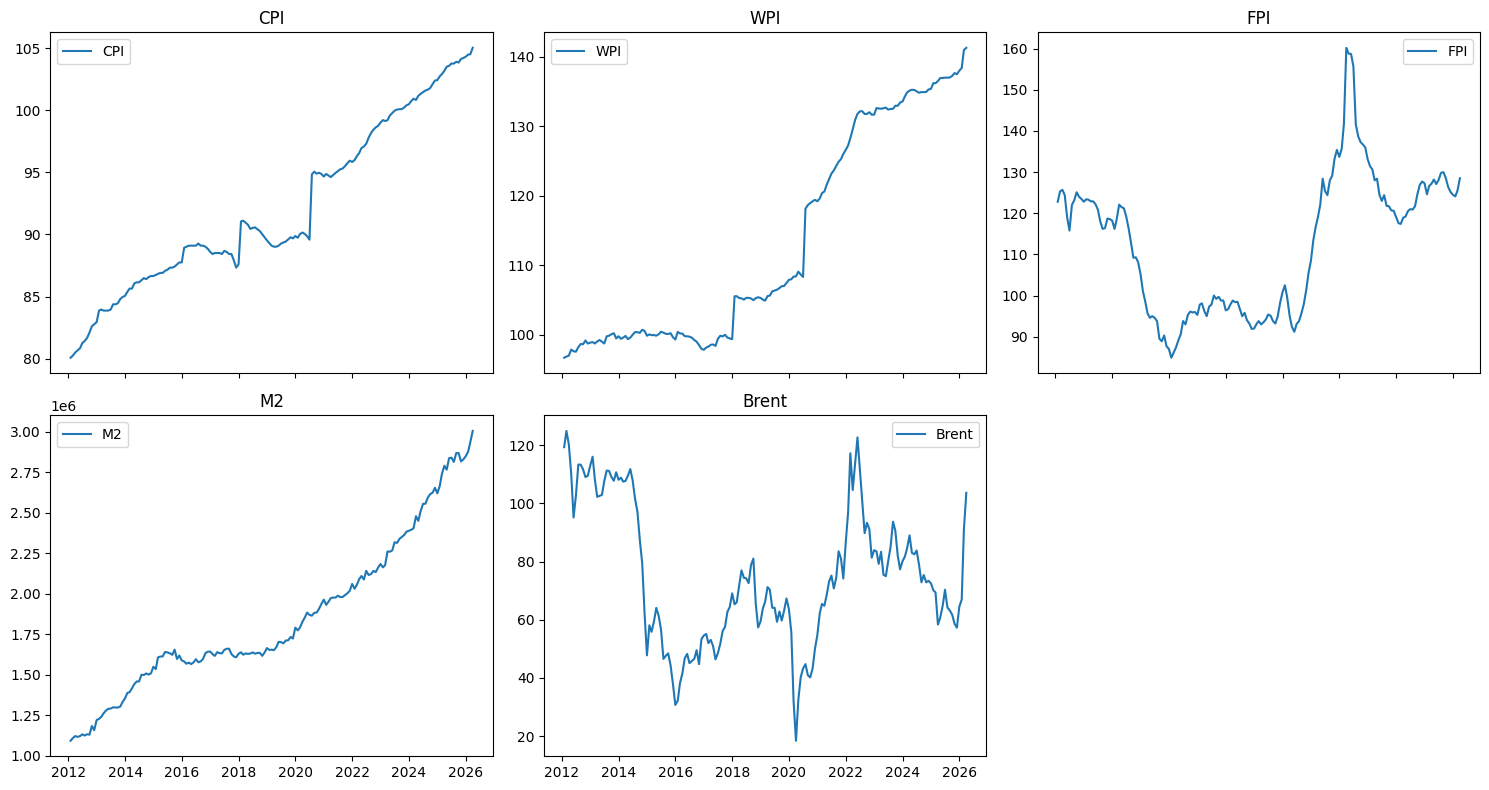

In [5]:
cols = ['CPI', 'WPI', 'FPI', 'M2', 'Brent']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.plot(df['Date'], df[col], label=col)
    ax.set_title(col)
    ax.legend()

for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# ADF Test

In [6]:
alpha = 0.05

for col in cols:
    series = df[col].dropna()
    adf_result = sm.tsa.stattools.adfuller(series, autolag='AIC')
    adf_stat, p_value, usedlag, nobs, crit_values, icbest = adf_result

    print(f"\n{col}")
    print(f"ADF Statistic: {adf_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Used lag: {usedlag}")
    print(f"Number of observations: {nobs}")
    print("Critical Values:")
    for key, value in crit_values.items():
        print(f"  {key}: {value:.4f}")

    if p_value < alpha and adf_stat < crit_values["5%"]:
        print("Interpretation: reject the null hypothesis of a unit root -> stationary")
    else:
        print("Interpretation: fail to reject the null hypothesis of a unit root -> non-stationary")


CPI
ADF Statistic: -0.2572
p-value: 0.9313
Used lag: 0
Number of observations: 170
Critical Values:
  1%: -3.4694
  5%: -2.8787
  10%: -2.5759
Interpretation: fail to reject the null hypothesis of a unit root -> non-stationary

WPI
ADF Statistic: 0.9073
p-value: 0.9932
Used lag: 0
Number of observations: 170
Critical Values:
  1%: -3.4694
  5%: -2.8787
  10%: -2.5759
Interpretation: fail to reject the null hypothesis of a unit root -> non-stationary

FPI
ADF Statistic: -1.5004
p-value: 0.5333
Used lag: 5
Number of observations: 165
Critical Values:
  1%: -3.4706
  5%: -2.8792
  10%: -2.5762
Interpretation: fail to reject the null hypothesis of a unit root -> non-stationary

M2
ADF Statistic: 1.4025
p-value: 0.9971
Used lag: 12
Number of observations: 158
Critical Values:
  1%: -3.4724
  5%: -2.8800
  10%: -2.5766
Interpretation: fail to reject the null hypothesis of a unit root -> non-stationary

Brent
ADF Statistic: -2.7490
p-value: 0.0659
Used lag: 1
Number of observations: 169
Crit

# Transformation

In [7]:
# Create a new dataframe with log-differenced transformations
df_transformed = df.copy()

for col in cols:
    # Calculate log differences: log(t) - log(t-1)
    df_transformed[col] = np.log(df[col]).diff()

# Display the first few rows to see the transformation
df_transformed.head(10)

,Date,CPI,WPI,FPI,M2,Brent
0,2012-01-31,NaN,NaN,NaN,NaN,NaN
1,2012-02-29,0.002108,0.001653,0.020154,0.015166,0.045861
2,2012-03-31,0.003148,0.001444,0.003187,0.011175,-0.037848
3,2012-04-30,0.002085,0.008929,-0.010396,-0.004541,-0.086339
4,2012-05-31,0.002093,-0.002455,-0.044379,0.004279,-0.148007
5,2012-06-30,0.005195,-0.000717,-0.027259,0.009548,0.075473
6,2012-07-31,0.002078,0.006844,0.052156,-0.006372,0.099536
7,2012-08-31,0.003102,0.004469,0.009788,0.007041,-0.000441
8,2012-09-30,0.005141,-0.000304,0.015304,-0.002439,-0.014221
9,2012-10-31,0.006144,0.005460,-0.008832,0.046376,-0.024008


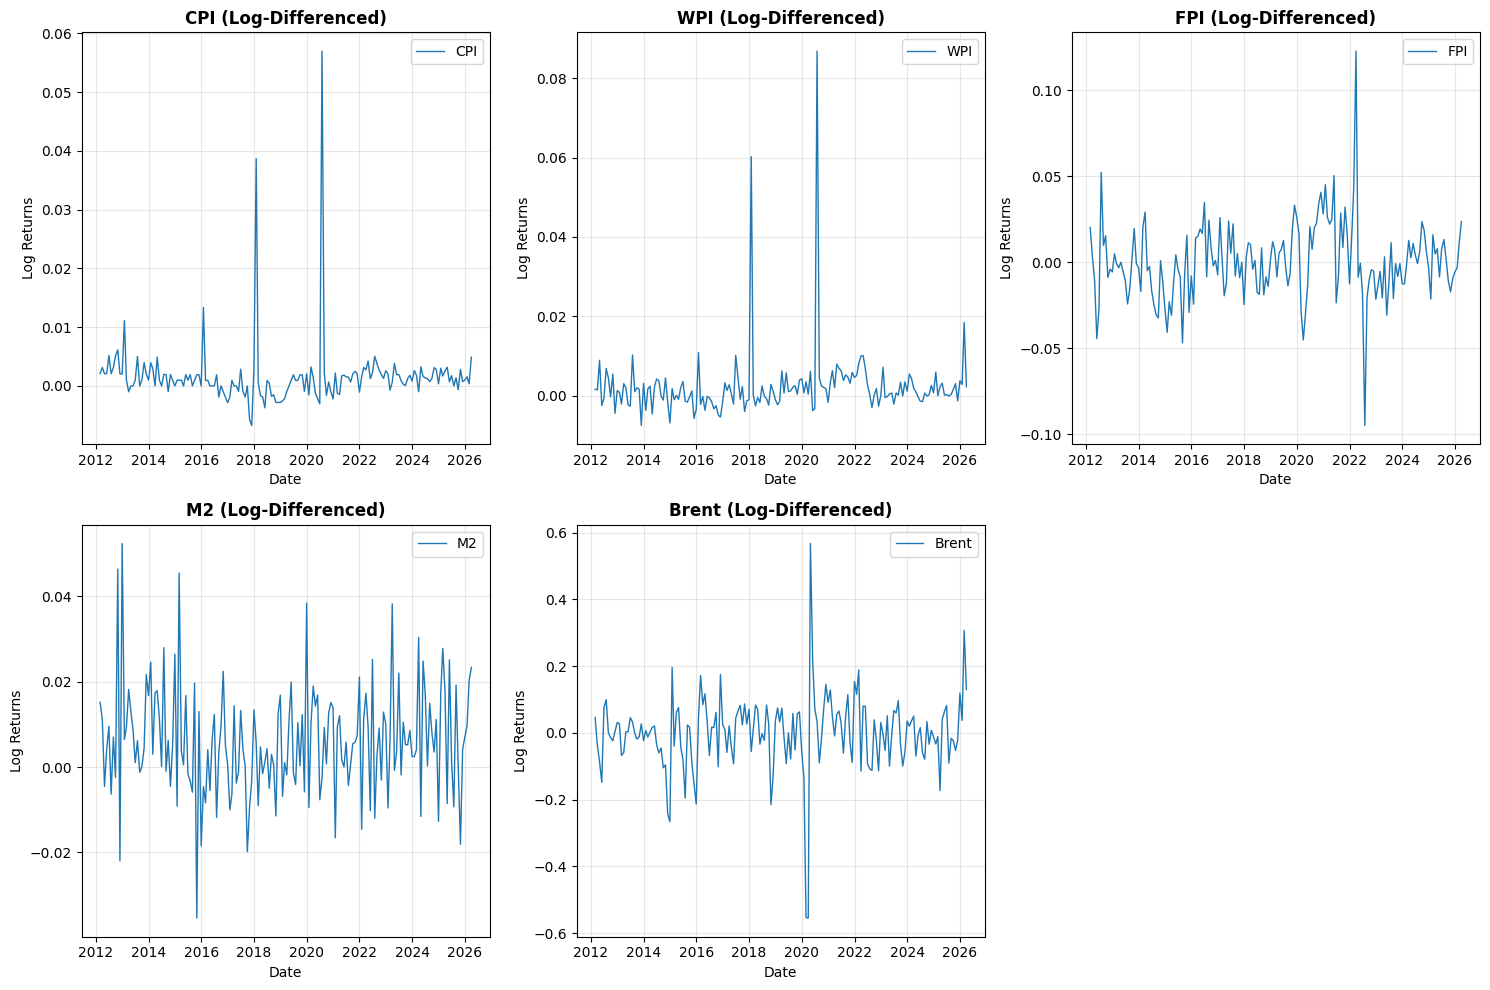

<Figure size 640x480 with 0 Axes>

In [8]:
# Plot transformed data in multiple graph styles
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.plot(df_transformed['Date'], df_transformed[col], label=col, linewidth=1)
    ax.set_title(f'{col} (Log-Differenced)', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Log Returns')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.tight_layout()
plt.show()


axes[5].set_visible(False)
plt.tight_layout()
plt.show()

# ADF Test after transformation

In [9]:
alpha = 0.05

for col in cols:
    series = df_transformed[col].dropna()
    adf_result = sm.tsa.stattools.adfuller(series, autolag='AIC')
    adf_stat, p_value, usedlag, nobs, crit_values, icbest = adf_result

    print(f"\n{col}")
    print(f"ADF Statistic: {adf_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Used lag: {usedlag}")
    print(f"Number of observations: {nobs}")
    print("Critical Values:")
    for key, value in crit_values.items():
        print(f"  {key}: {value:.4f}")

    if p_value < alpha and adf_stat < crit_values["5%"]:
        print("Interpretation: reject the null hypothesis of a unit root -> stationary")
    else:
        print("Interpretation: fail to reject the null hypothesis of a unit root -> non-stationary")


CPI
ADF Statistic: -12.6195
p-value: 0.0000
Used lag: 0
Number of observations: 169
Critical Values:
  1%: -3.4696
  5%: -2.8788
  10%: -2.5760
Interpretation: reject the null hypothesis of a unit root -> stationary

WPI
ADF Statistic: -12.9595
p-value: 0.0000
Used lag: 0
Number of observations: 169
Critical Values:
  1%: -3.4696
  5%: -2.8788
  10%: -2.5760
Interpretation: reject the null hypothesis of a unit root -> stationary

FPI
ADF Statistic: -8.6066
p-value: 0.0000
Used lag: 0
Number of observations: 169
Critical Values:
  1%: -3.4696
  5%: -2.8788
  10%: -2.5760
Interpretation: reject the null hypothesis of a unit root -> stationary

M2
ADF Statistic: -2.5159
p-value: 0.1116
Used lag: 11
Number of observations: 158
Critical Values:
  1%: -3.4724
  5%: -2.8800
  10%: -2.5766
Interpretation: fail to reject the null hypothesis of a unit root -> non-stationary

Brent
ADF Statistic: -9.7102
p-value: 0.0000
Used lag: 1
Number of observations: 168
Critical Values:
  1%: -3.4699
  5%:

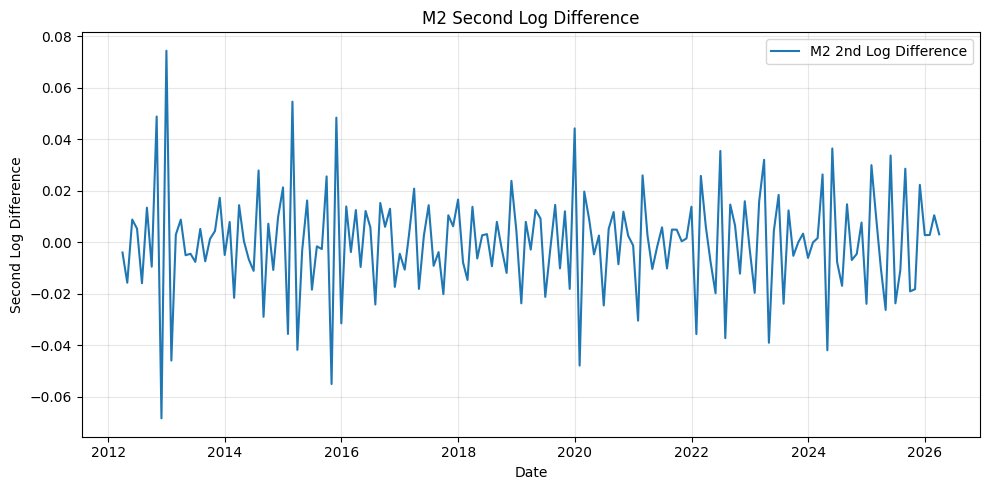

M2 Second Log Difference ADF Test
ADF Statistic: -7.4475
p-value: 0.0000
Used lag: 11
Number of observations: 157
Critical Values:
  1%: -3.4727
  5%: -2.8801
  10%: -2.5767
Interpretation: reject the null hypothesis of a unit root -> stationary


In [10]:
### Since all of them are stationary in the first diff log except for m2, we will try the second log diff for m2 and assume 
#    there's no cointegration between m2 and the other variables, which is a strong assumption but we will go with it for now.

m2_log_diff2 = np.log(df['M2']).diff().diff()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Date'], m2_log_diff2, label='M2 2nd Log Difference', color='tab:blue')
ax.set_title('M2 Second Log Difference')
ax.set_xlabel('Date')
ax.set_ylabel('Second Log Difference')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

series = m2_log_diff2.dropna()
adf_result_m2 = sm.tsa.stattools.adfuller(series, autolag='AIC')
adf_stat, p_value, usedlag, nobs, crit_values, icbest = adf_result_m2

print("M2 Second Log Difference ADF Test")
print(f"ADF Statistic: {adf_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Used lag: {usedlag}")
print(f"Number of observations: {nobs}")
print("Critical Values:")
for key, value in crit_values.items():
    print(f"  {key}: {value:.4f}")

if p_value < alpha and adf_stat < crit_values["5%"]:
    print("Interpretation: reject the null hypothesis of a unit root -> stationary")
else:
    print("Interpretation: fail to reject the null hypothesis of a unit root -> non-stationary")

In [11]:
# Create a dataframe with stationary variables
# All variables are stationary at first log difference except M2 (stationary at second log difference)

df_stationary = df_transformed[['Date', 'CPI', 'WPI', 'FPI', 'Brent']].copy()
df_stationary['M2'] = m2_log_diff2

# Drop the first row(s) with NaN values
df_stationary = df_stationary.dropna()

print(df_stationary.head(10))
print(f"\nShape: {df_stationary.shape}")
print(f"\nData types:\n{df_stationary.dtypes}")

         Date       CPI       WPI       FPI     Brent        M2
2  2012-03-31  0.003148  0.001444  0.003187 -0.037848 -0.003992
3  2012-04-30  0.002085  0.008929 -0.010396 -0.086339 -0.015716
4  2012-05-31  0.002093 -0.002455 -0.044379 -0.148007  0.008820
5  2012-06-30  0.005195 -0.000717 -0.027259  0.075473  0.005269
6  2012-07-31  0.002078  0.006844  0.052156  0.099536 -0.015920
7  2012-08-31  0.003102  0.004469  0.009788 -0.000441  0.013413
8  2012-09-30  0.005141 -0.000304  0.015304 -0.014221 -0.009481
9  2012-10-31  0.006144  0.005460 -0.008832 -0.024008  0.048815
10 2012-11-30  0.002032 -0.004446 -0.004040  0.003935 -0.068367
11 2012-12-31  0.002040  0.001316 -0.005684  0.031201  0.074360

Shape: (169, 6)

Data types:
Date     datetime64[ns]
CPI             float64
WPI             float64
FPI             float64
Brent           float64
M2              float64
dtype: object


# Model Selection: VAR vs. VECM

To test for long-run equilibrium relationships (cointegration), standard procedures like the Johansen test require all variables to be integrated of the same order, typically $I(1)$. Based on our ADF unit root tests, our system contains a mix of integration orders: CPI, WPI, FPI, and Brent are $I(1)$, while M2 is $I(2)$.Because the pre-conditions for standard cointegration testing are not met by the inclusion of an $I(2)$ variable, we cannot estimate a Vector Error Correction Model (VECM). Therefore, we proceed by differencing all variables to achieve stationarity and estimating a standard unrestricted Vector Autoregression (VAR) model.

# Optimal Lag Length

In [21]:
# We will use AIC to select the optmal lag length for the VAR model.

from statsmodels.tsa.api import VAR

# Prepare data for VAR model
data_for_var = df_stationary[['CPI', 'WPI', 'FPI', 'Brent', 'M2']].values

# Create VAR model
model = VAR(data_for_var)

# Select lag length using AIC
lag_order = model.select_order(maxlags=12)

print("=" * 70)
print("LAG LENGTH SELECTION RESULTS")
print("=" * 70)
print(lag_order.summary())

LAG LENGTH SELECTION RESULTS
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -41.39      -41.29   1.062e-18      -41.35
1       -41.98     -41.40*   5.869e-19     -41.74*
2       -42.16      -41.09   4.898e-19      -41.73
3      -42.25*      -40.69  4.484e-19*      -41.62
4       -42.17      -40.12   4.896e-19      -41.34
5       -42.07      -39.54   5.418e-19      -41.05
6       -42.02      -39.00   5.808e-19      -40.79
7       -41.85      -38.35   6.933e-19      -40.43
8       -41.80      -37.81   7.486e-19      -40.18
9       -41.60      -37.12   9.373e-19      -39.78
10      -41.46      -36.49   1.119e-18      -39.44
11      -41.52      -36.07   1.093e-18      -39.31
12      -41.54      -35.61   1.126e-18      -39.13
--------------------------------------------------


# Inverse roots VAR(3)

Selected lag order: 3
Inverse roots of the VAR characteristic polynomial:
  Root 1: -0.0157-0.0000j  |  abs = 0.0157
  Root 2: -0.1365-0.0000j  |  abs = 0.1365
  Root 3: -0.4445-0.0000j  |  abs = 0.4445
  Root 4: 0.4767-0.2799j  |  abs = 0.5528
  Root 5: 0.4767+0.2799j  |  abs = 0.5528
  Root 6: -0.1188-0.5538j  |  abs = 0.5664
  Root 7: -0.1188+0.5538j  |  abs = 0.5664
  Root 8: -0.3957-0.4436j  |  abs = 0.5944
  Root 9: -0.3957+0.4436j  |  abs = 0.5944
  Root 10: -0.6418-0.0000j  |  abs = 0.6418
  Root 11: -0.2397-0.6111j  |  abs = 0.6564
  Root 12: -0.2397+0.6111j  |  abs = 0.6564
  Root 13: 0.2817-0.6262j  |  abs = 0.6866
  Root 14: 0.2817+0.6262j  |  abs = 0.6866
  Root 15: 0.7487+0.0000j  |  abs = 0.7487

Model stability check:
  All inverse roots inside the unit circle: True


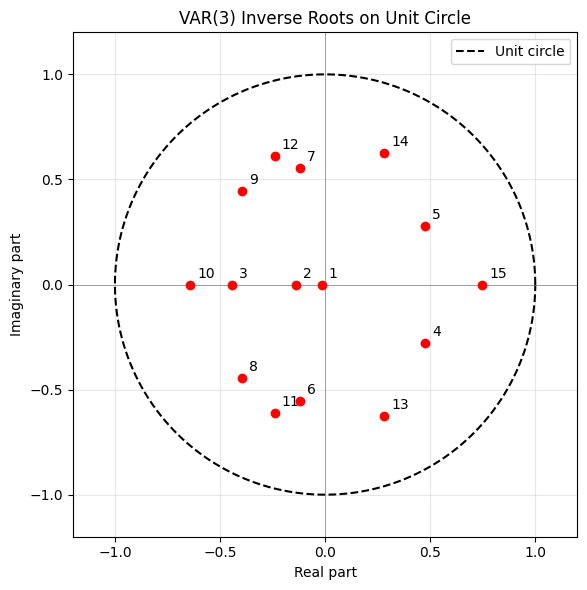

In [14]:
selected_lag = None
if hasattr(lag_order, "selected_orders"):
    selected_lag = lag_order.selected_orders.get("aic", None)
if selected_lag is None:
    selected_lag = 1

var_results = model.fit(selected_lag)

inv_roots = 1 / var_results.roots
inv_root_abs = np.abs(inv_roots)

print(f"Selected lag order: {selected_lag}")
print("Inverse roots of the VAR characteristic polynomial:")
for i, root in enumerate(inv_roots, 1):
    print(f"  Root {i}: {root:.4f}  |  abs = {np.abs(root):.4f}")

stable = np.all(inv_root_abs < 1)
print("\nModel stability check:")
print(f"  All inverse roots inside the unit circle: {stable}")

theta = np.linspace(0, 2 * np.pi, 400)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(np.cos(theta), np.sin(theta), color="black", linestyle="--", label="Unit circle")
ax.scatter(inv_roots.real, inv_roots.imag, color="red", zorder=5)
for i, root in enumerate(inv_roots, 1):
    ax.annotate(str(i), (root.real, root.imag), textcoords="offset points", xytext=(5, 5))

ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
ax.set_title(f"VAR({selected_lag}) Inverse Roots on Unit Circle")
ax.set_xlabel("Real part")
ax.set_ylabel("Imaginary part")
ax.set_aspect("equal")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# LM Test for VAR Model Stability (Lagrange Multiplier Test for Serial Correlation)

lm_test_result = var_results.test_whiteness(nlags=selected_lag + 1, signif=0.05)

print("=" * 70)
print("LAGRANGE MULTIPLIER TEST FOR SERIAL CORRELATION")
print("=" * 70)
print(f"\nTest Statistic: {lm_test_result.test_statistic:.4f}")
print(f"P-value: {lm_test_result.pvalue:.4f}")
print(f"Degrees of Freedom: {lm_test_result.df}")

alpha = 0.05
if lm_test_result.pvalue > alpha:
    print(f"\nInterpretation: p-value ({lm_test_result.pvalue:.4f}) > α ({alpha})")
    print("Fail to reject the null hypothesis -> No serial correlation detected")
    print("The VAR model residuals are white noise -> Model is adequate")
else:
    print(f"\nInterpretation: p-value ({lm_test_result.pvalue:.4f}) ≤ α ({alpha})")
    print("Reject the null hypothesis -> Serial correlation detected")
    print("The VAR model may need adjustment (e.g., increase lag order)")

print("\n" + "=" * 70)
print(f"Overall Model Stability: {'STABLE' if stable else 'UNSTABLE'}")
print("=" * 70)

LAGRANGE MULTIPLIER TEST FOR SERIAL CORRELATION

Test Statistic: 50.6518
P-value: 0.0018
Degrees of Freedom: 25

Interpretation: p-value (0.0018) ≤ α (0.05)
Reject the null hypothesis -> Serial correlation detected
The VAR model may need adjustment (e.g., increase lag order)

Overall Model Stability: STABLE


# Granger Causality

In [16]:
variables = ['WPI', 'FPI', 'Brent', 'M2']
maxlag = int(selected_lag) if selected_lag is not None else 6
alpha = 0.05

for var in variables:
    print(f"\nGranger causality test: {var} -> CPI (maxlag={maxlag})")
    test_data = df_stationary[['CPI', var]].dropna().values
    gc_results = sm.tsa.stattools.grangercausalitytests(test_data, maxlag=maxlag, verbose=False)

    for lag, res in gc_results.items():
        ssr_ftest_p = res[0]['ssr_ftest'][1]
        ssr_chi2test_p = res[0]['ssr_chi2test'][1]
        print(
            f" lag {lag}: ssr_ftest p={ssr_ftest_p:.4f} | "
            f"ssr_chi2test p={ssr_chi2test_p:.4f} | "
            f"{'reject H0' if ssr_ftest_p < alpha else 'fail to reject H0'}"
        )


Granger causality test: WPI -> CPI (maxlag=3)
 lag 1: ssr_ftest p=0.2611 | ssr_chi2test p=0.2552 | fail to reject H0
 lag 2: ssr_ftest p=0.4488 | ssr_chi2test p=0.4360 | fail to reject H0
 lag 3: ssr_ftest p=0.1933 | ssr_chi2test p=0.1726 | fail to reject H0

Granger causality test: FPI -> CPI (maxlag=3)
 lag 1: ssr_ftest p=0.8076 | ssr_chi2test p=0.8056 | fail to reject H0
 lag 2: ssr_ftest p=0.6157 | ssr_chi2test p=0.6057 | fail to reject H0
 lag 3: ssr_ftest p=0.5667 | ssr_chi2test p=0.5471 | fail to reject H0

Granger causality test: Brent -> CPI (maxlag=3)
 lag 1: ssr_ftest p=0.9502 | ssr_chi2test p=0.9497 | fail to reject H0
 lag 2: ssr_ftest p=0.3622 | ssr_chi2test p=0.3487 | fail to reject H0
 lag 3: ssr_ftest p=0.0000 | ssr_chi2test p=0.0000 | reject H0

Granger causality test: M2 -> CPI (maxlag=3)
 lag 1: ssr_ftest p=0.8476 | ssr_chi2test p=0.8460 | fail to reject H0
 lag 2: ssr_ftest p=0.9221 | ssr_chi2test p=0.9198 | fail to reject H0
 lag 3: ssr_ftest p=0.9811 | ssr_chi2t

/Users/az/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/az/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/az/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/az/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


# Impulse Response Function with CPI as the Responser

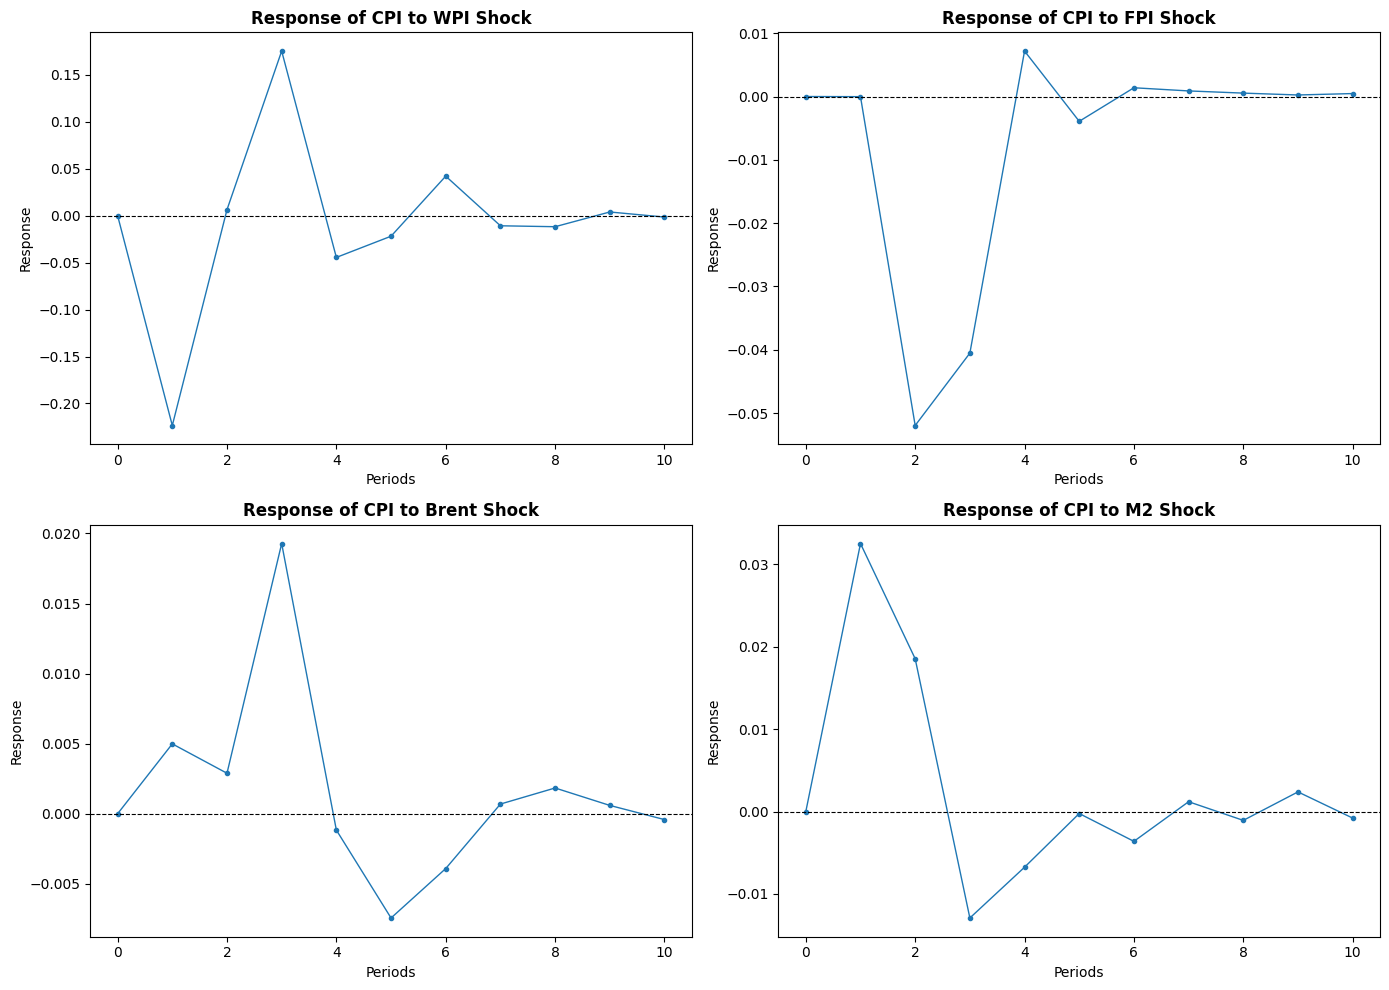

In [17]:
from statsmodels.tsa.vector_ar.var_model import VARResultsWrapper

# Impulse Response Analysis
# CPI as the responder, other variables as impulsers

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

impulsers = ['WPI', 'FPI', 'Brent', 'M2']
cpi_index = 0  # CPI is the first variable in df_stationary

# Get impulse response functions
irf = var_results.irf(10)

for ax, impulser in zip(axes, impulsers):
    impulser_index = list(df_stationary[['CPI', 'WPI', 'FPI', 'Brent', 'M2']].columns).index(impulser)
    
    # Extract impulse response of CPI to shock in impulser
    response = irf.irfs[:, cpi_index, impulser_index]
    
    ax.plot(response, marker='o', linewidth=1, markersize=3)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8)
    ax.set_title(f'Response of CPI to {impulser} Shock', fontweight='bold')
    ax.set_xlabel('Periods')
    ax.set_ylabel('Response')
    #ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# FEVD for CPI

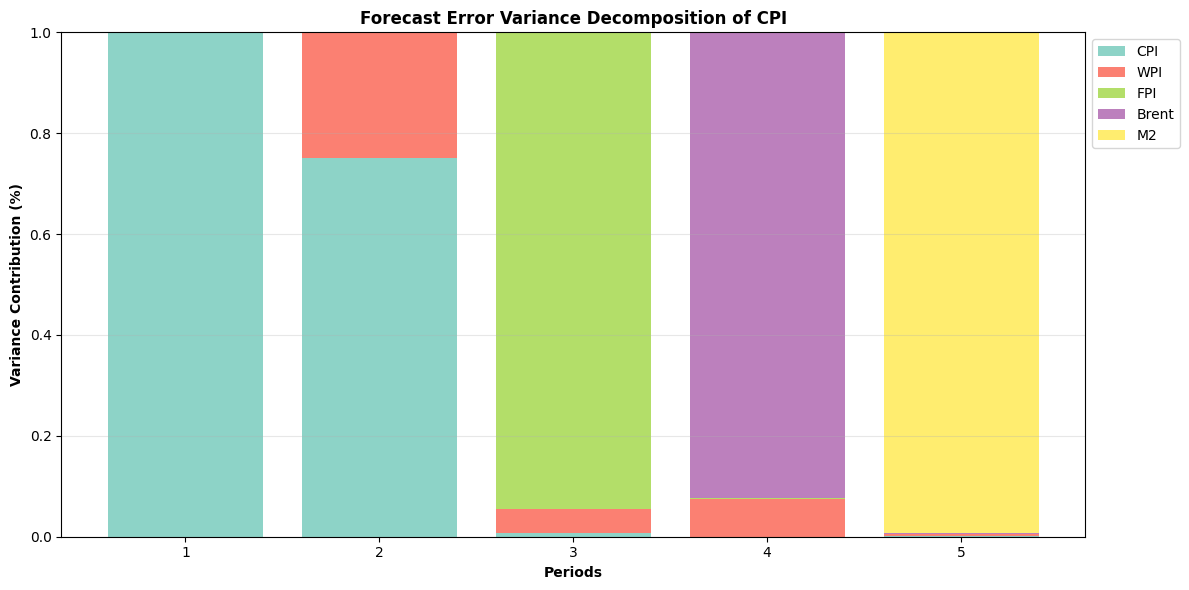

FORECAST ERROR VARIANCE DECOMPOSITION OF CPI

Period              CPI          WPI          FPI        Brent           M2
--------------------------------------------------------------------------------
1                 1.00%        0.00%        0.00%        0.00%        0.00%
2                 0.75%        0.25%        0.00%        0.00%        0.00%
3                 0.01%        0.05%        0.94%        0.00%        0.00%
4                 0.00%        0.07%        0.00%        0.92%        0.00%
5                 0.00%        0.00%        0.00%        0.00%        0.99%


In [18]:
# Forecast Error Variance Decomposition (FEVD) for CPI
fevd = var_results.fevd(10)

# Extract FEVD for CPI (first variable)
cpi_fevd = fevd.decomp[:, 0, :]

# Create a stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))

periods = np.arange(1, cpi_fevd.shape[0] + 1)
variables_list = ['CPI', 'WPI', 'FPI', 'Brent', 'M2']

bottom = np.zeros(cpi_fevd.shape[0])
colors = plt.cm.Set3(np.linspace(0, 1, len(variables_list)))

for i, var in enumerate(variables_list):
    ax.bar(periods, cpi_fevd[:, i], bottom=bottom, label=var, color=colors[i])
    bottom += cpi_fevd[:, i]

ax.set_xlabel('Periods', fontweight='bold')
ax.set_ylabel('Variance Contribution (%)', fontweight='bold')
ax.set_title('Forecast Error Variance Decomposition of CPI', fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print FEVD table
print("=" * 80)
print("FORECAST ERROR VARIANCE DECOMPOSITION OF CPI")
print("=" * 80)
print(f"\n{'Period':<10} {' '.join([f'{v:>12}' for v in variables_list])}")
print("-" * 80)
for i, period in enumerate(periods):
    print(f"{period:<10} {' '.join([f'{cpi_fevd[i, j]:>11.2f}%' for j in range(len(variables_list))])}")

# Forecasting Graph

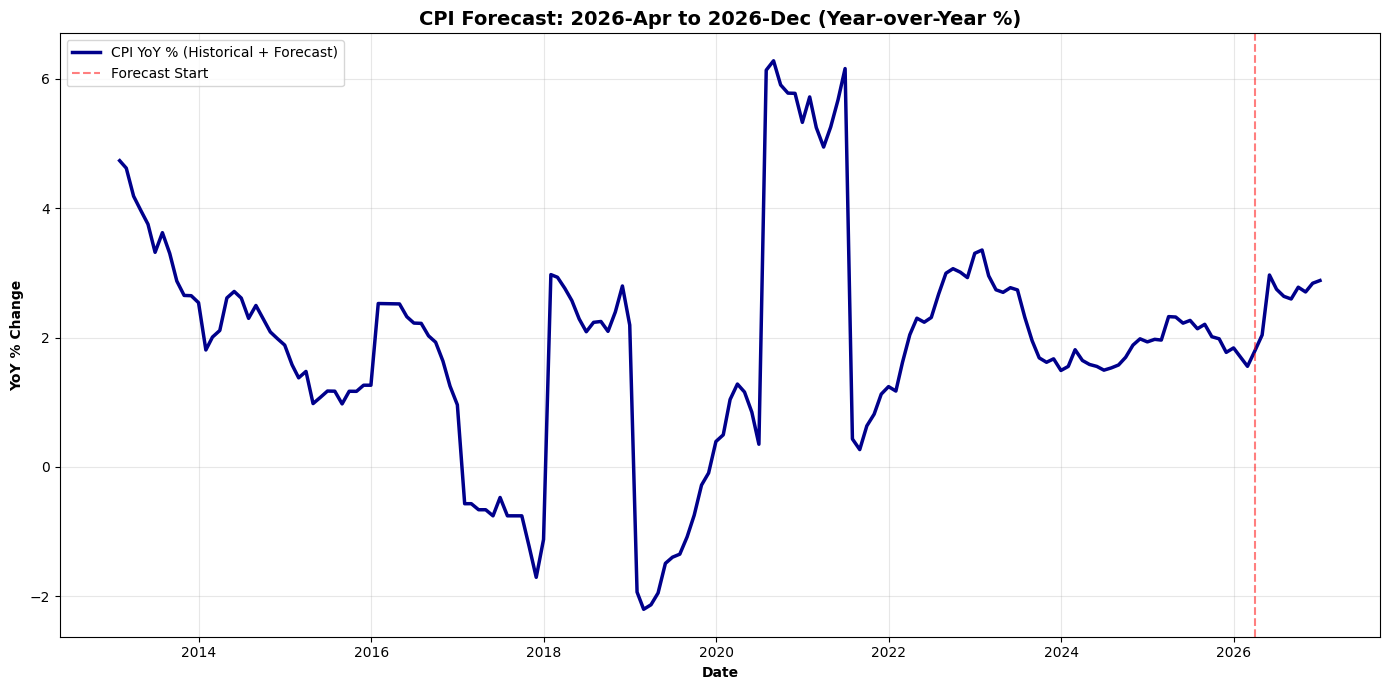

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare the forecast series
forecast_series = pd.Series(yoy_pct, index=forecast_dates)

# 2. Ensure historical index is datetime (important for alignment)
historical_yoy.index = pd.to_datetime(df['Date'])

# 3. Combine them into one single continuous series
combined_series = pd.concat([historical_yoy, forecast_series])

# 4. Create the plot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot the continuous line
ax.plot(combined_series.index, combined_series.values, 
        label='CPI YoY % (Historical + Forecast)', 
        linewidth=2.5, color='darkblue')

# Optional: Add a vertical line to show where the forecast begins
ax.axvline(x=historical_yoy.index[-1], color='red', linestyle='--', alpha=0.5, label='Forecast Start')

# 5. Formatting
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('YoY % Change', fontweight='bold')
ax.set_title('CPI Forecast: 2026-Apr to 2026-Dec (Year-over-Year %)', fontweight='bold', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# 6. Final display
plt.tight_layout()
plt.show()

# Forecating Table

In [ ]:
import pandas as pd

# 1. Identify your last known CPI value
# If your main dataframe is named 'df', use this:
last_historical_cpi = df['CPI'].iloc[-1] 

# 2. Reconstruct the forecasted levels
# (Using the YoY percentage to project the index forward)
forecast_cpi_levels = []
for i in range(len(yoy_pct)):
    # We apply the growth rate to the base index
    level = last_historical_cpi * (1 + (yoy_pct[i] / 100))
    forecast_cpi_levels.append(level)

# 3. Create the table
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'CPI_Level_Forecast': forecast_cpi_levels,
    'YoY_Growth': yoy_pct
})

# 4. Formatting for the final report
forecast_df['Date'] = pd.to_datetime(forecast_df['Date']).dt.strftime('%Y-%b')
forecast_df['CPI_Level_Forecast'] = forecast_df['CPI_Level_Forecast'].map('{:.2f}'.format)
forecast_df['YoY_Growth'] = forecast_df['YoY_Growth'].map('{:.2f}%'.format)

print("--- Saudi CPI Forecast Table (2026) ---")
print(forecast_df.to_string(index=False))

--- Saudi CPI Forecast Table (2026) ---
    Date CPI_Level_Forecast YoY_Growth
2026-Apr             107.16      2.04%
2026-May             108.13      2.97%
2026-Jun             107.90      2.75%
2026-Jul             107.79      2.64%
2026-Aug             107.74      2.60%
2026-Sep             107.94      2.78%
2026-Oct             107.86      2.71%
2026-Nov             108.00      2.84%
2026-Dec             108.04      2.88%


# Data Sources: GASTAT, SAMA, FAO, Platts, Investing